# Europa intera per mese

Questo notebook serve per leggere e visualizzare il dataset finale dei 3 indicatori minimi nel formato `Europa intera per mese`.

In [5]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv

project_root = Path.cwd()
if not (project_root / 'scripts').exists():
    project_root = project_root.parent

load_dotenv(project_root / '.env')
project_output_dir = Path(os.getenv('PROJECT_OUTPUT_DIR', ''))

candidates = [
    project_output_dir / 'europe_month_indicators.csv' if str(project_output_dir) else None,
    project_root / 'outputs' / 'local_preview' / 'europe_month_indicators.csv',
]
csv_path = next(path for path in candidates if path and path.exists())
csv_path

PosixPath('/Volumes/Archivio/biomap_thesis/outputs/europe_month_indicators.csv')

In [6]:
df = pd.read_csv(csv_path)
df['month'] = pd.to_datetime(df['month'])
df.head()

,month,species_count_europe,temperature_mean_europe_c,precipitation_mean_europe_mm
0,2000-01-01,20,3.270349,2.301371
1,2000-02-01,15,3.262201,2.327262
2,2000-03-01,21,3.179468,2.336039
3,2000-04-01,21,4.298975,2.355669
4,2000-05-01,21,5.842889,2.407766


In [7]:
df.describe(include='all')

,month,species_count_europe,temperature_mean_europe_c,precipitation_mean_europe_mm
count,12,12.000000,12.000000,12.000000
mean,2000-06-16 08:00:00,20.166667,5.132461,2.402782
min,2000-01-01 00:00:00,15.000000,3.179468,2.301371
25%,2000-03-24 06:00:00,19.750000,3.621065,2.335634
50%,2000-06-16 00:00:00,21.000000,4.584344,2.381717
75%,2000-09-08 12:00:00,21.000000,6.544511,2.477027
max,2000-12-01 00:00:00,22.000000,7.685602,2.514933
std,NaN,1.992410,1.736576,0.078691


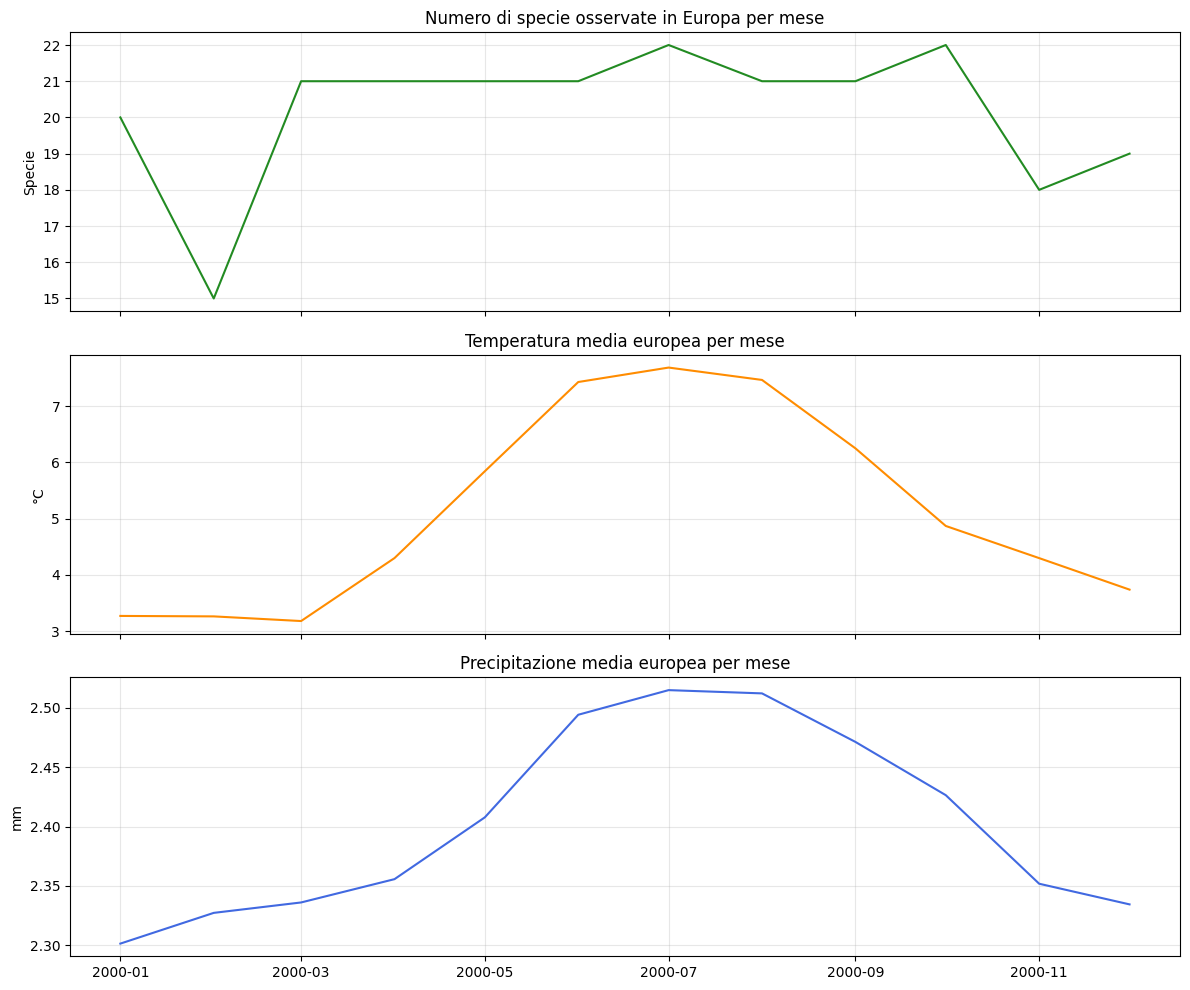

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(df['month'], df['species_count_europe'], color='forestgreen')
axes[0].set_title('Numero di specie osservate in Europa per mese')
axes[0].set_ylabel('Specie')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df['month'], df['temperature_mean_europe_c'], color='darkorange')
axes[1].set_title('Temperatura media europea per mese')
axes[1].set_ylabel('°C')
axes[1].grid(True, alpha=0.3)

axes[2].plot(df['month'], df['precipitation_mean_europe_mm'], color='royalblue')
axes[2].set_title('Precipitazione media europea per mese')
axes[2].set_ylabel('mm')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()